# DSN Mart Sales Prediction — Full Pipeline

In [1]:
!pip install -q lightgbm xgboost catboost optuna

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import optuna
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

## 1. Load Data
Using kagglehub to load dataset

In [3]:
# Install kagglehub
%pip install -q -U kagglehub

In [4]:
import os
from google.colab import userdata
import kagglehub

# Authenticate using the secret
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

# Download the dataset
path = kagglehub.competition_download('dsn-bootcamp-qualification-hackathon-2026-ml-track')

print("Dataset downloaded to:", path)

Dataset downloaded to: /root/.cache/kagglehub/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track


In [5]:
from pathlib import Path

# Find CSVs in directory
csv_files = list(Path(path).rglob("*.csv"))
print(csv_files)

[PosixPath('/root/.cache/kagglehub/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv'), PosixPath('/root/.cache/kagglehub/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv'), PosixPath('/root/.cache/kagglehub/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv')]


In [6]:
train = pd.read_csv(csv_files[0])
test = pd.read_csv(csv_files[2])

print(train.shape, test.shape)
train.head()

(6818, 13) (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [7]:
train.describe(include="all")

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
count,6818,6818,5593.000000,6818,6818.000000,6818,6818.000000,6818,6818.000000,4899,6818,6818,6818.000000
unique,6818,1555,NaN,2,NaN,48,NaN,10,NaN,3,3,4,NaN
top,row_08522,PRD-YZB4K8,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,STORE-YLW,NaN,Medium,Tier_3,Standard Supermarket,NaN
freq,1,9,NaN,4425,NaN,480,NaN,754,NaN,2218,2677,4462,NaN
mean,NaN,NaN,12.850876,NaN,0.065527,NaN,140.473623,NaN,34.178205,NaN,NaN,NaN,2174.756574
std,NaN,NaN,4.646542,NaN,0.051566,NaN,62.413513,NaN,8.384574,NaN,NaN,NaN,1697.894956
min,NaN,NaN,4.482000,NaN,0.000000,NaN,31.110000,NaN,23.000000,NaN,NaN,NaN,32.700000
25%,NaN,NaN,8.750000,NaN,0.026600,NaN,93.280000,NaN,28.000000,NaN,NaN,NaN,834.792500
50%,NaN,NaN,12.647000,NaN,0.053200,NaN,142.065000,NaN,33.000000,NaN,NaN,NaN,1790.890000
75%,NaN,NaN,16.894000,NaN,0.093400,NaN,185.987500,NaN,45.000000,NaN,NaN,NaN,3092.587500


In [8]:
train['is_train'] = 1
test['is_train'] = 0
test['total_sales'] = np.nan

full = pd.concat([train, test], axis=0, ignore_index=True)
full.shape

(8523, 14)

## 2. Data Exploration

Checking the structural presentation of the datasets

In [9]:
train.info()
print("\nDuplicate rows:", train.duplicated().sum())
print("Unique product_code:", train['product_code'].nunique())
print("Unique store_code:", train['store_code'].nunique())

train_products, test_products = set(train['product_code']), set(test['product_code'])
train_stores, test_stores = set(train['store_code']), set(test['store_code'])
print("Products in test not seen in train:", len(test_products - train_products))
print("Stores in test not seen in train:", len(test_stores - train_stores))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
 13  is_train             6818 non-null   int64  
dtypes: float64(4), int64(2), object(8)
memory usage: 745.8+ KB

Duplicate rows: 0
Unique pro

In [10]:
print(test_products - train_products)

{'PRD-E6K088', 'PRD-RCD9SI', 'PRD-GSRI2A', 'PRD-CXBJQ3'}


In [11]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print("\n% missing:")
print((missing / len(train) * 100).round(2))

store_size           1919
product_weight_kg    1225
dtype: int64

% missing:
store_size           28.15
product_weight_kg    17.97
dtype: float64


The store_size column was missing 28%, while the product_weight_kg column was missing 18%, both large enough to consider a structured imputation strategy rather than a blanket drop.

In [12]:
for col in ['fat_content', 'product_category', 'store_size', 'store_location_tier', 'store_format']:
    print(f"\n-- {col} --")
    print(train[col].value_counts(dropna=False))


-- fat_content --
fat_content
Low Fat    4425
Regular    2393
Name: count, dtype: int64

-- product_category --
product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269
fruits and vegetables    265
FRUITS AND VEGETABLES    261
Baking Goods             254
snack foods              236
SNACK FOODS              229
Health and Hygiene       197
HOUSEHOLD                185
Soft Drinks              178
frozen foods             177
FROZEN FOODS             172
household                168
Meat                     157
DAIRY                    143
dairy                    142
BAKING GOODS             137
canned                   129
baking goods             125
CANNED                   117
health and hygiene       116
Breads                   110
SOFT DRINKS              100
HEALTH AND HYGIENE        99
MEAT                      94
Hard Drinks               92


Checking the categorical columns: product_category had 48 raw values that were just 16 categories in three different cases (Title/lower/UPPER). The other columns were clean

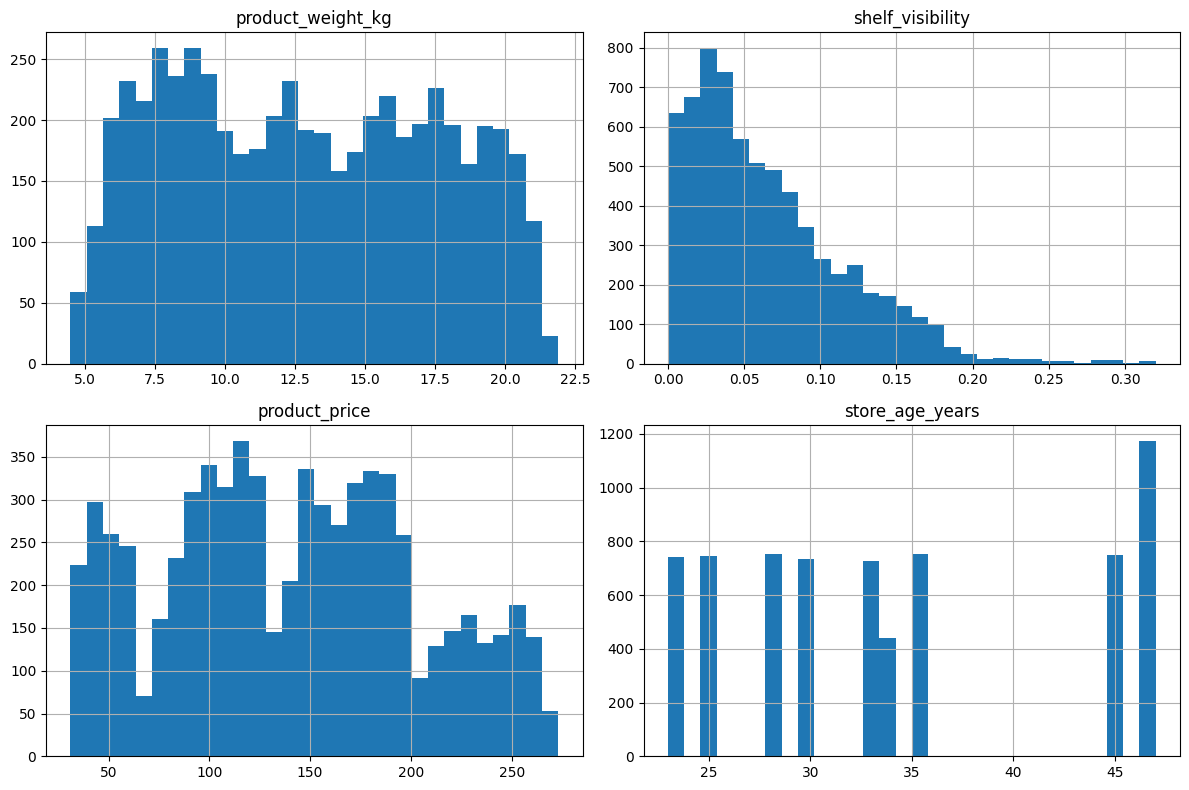

In [13]:
numeric_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']
train[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

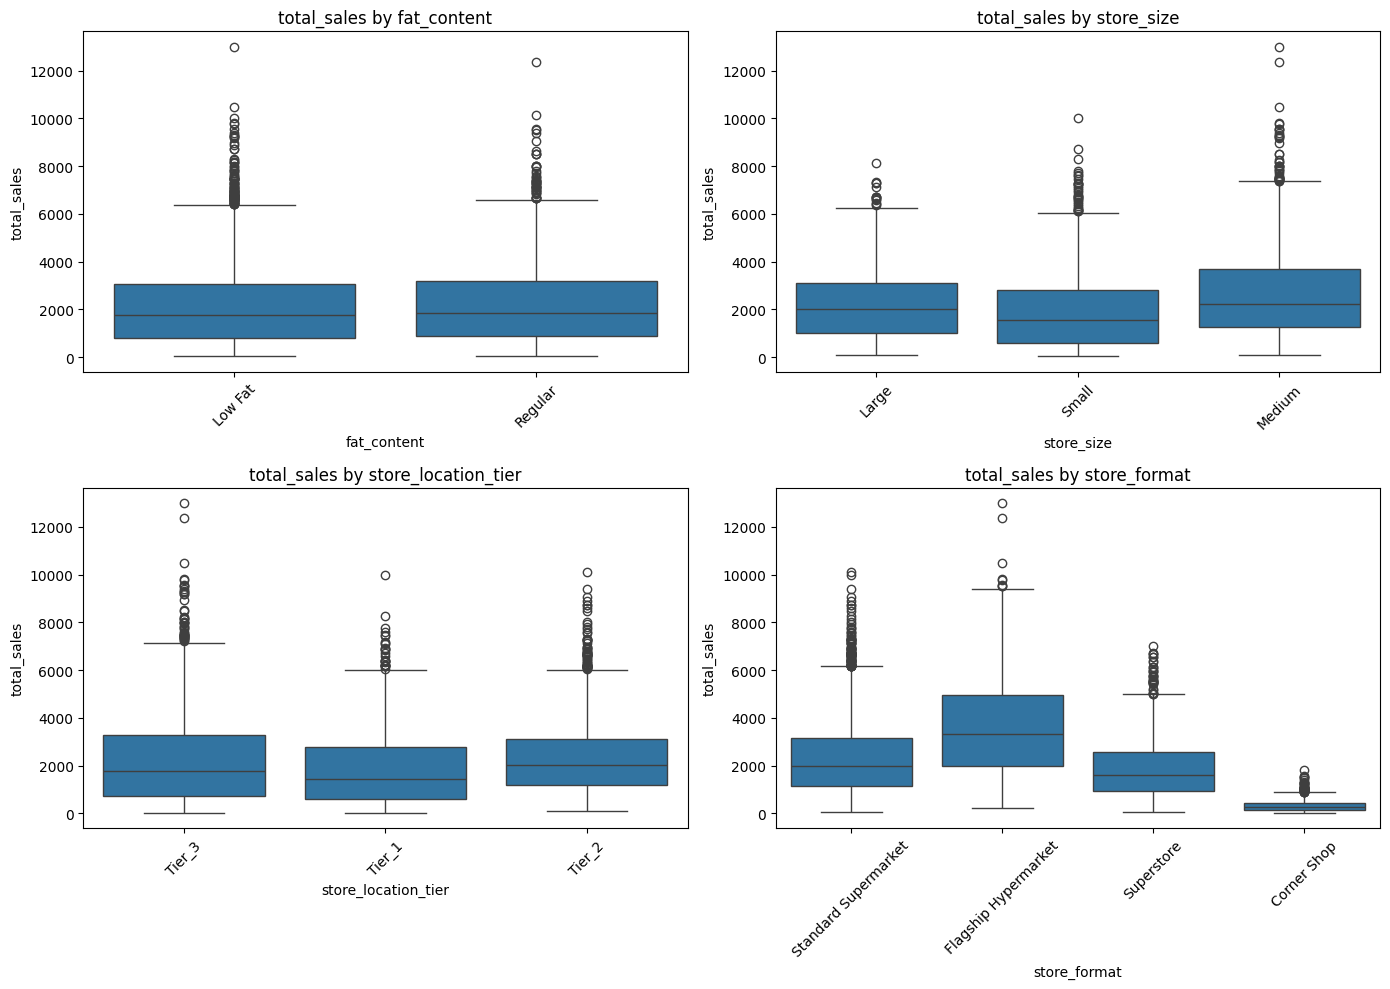

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_cols = ['fat_content', 'store_size', 'store_location_tier', 'store_format']
for ax, col in zip(axes.flat, cat_cols):
    sns.boxplot(data=train, x=col, y='total_sales', ax=ax)
    ax.set_title(f'total_sales by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

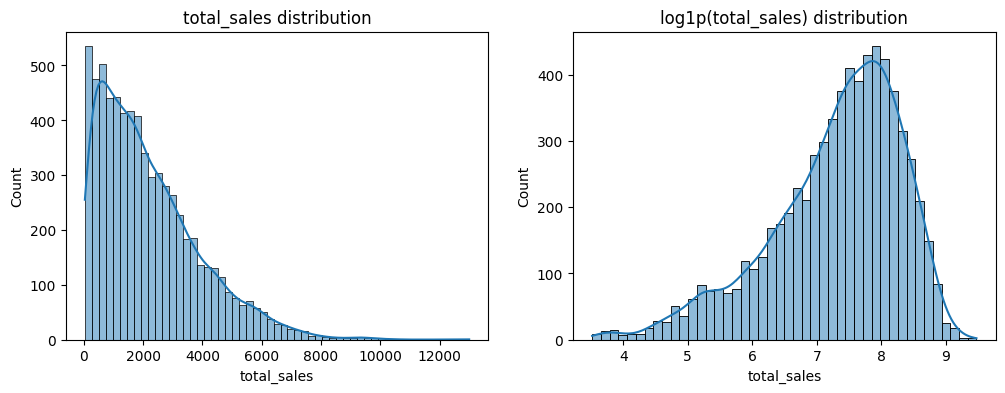

,total_sales
count,6818.000000
mean,2174.756574
std,1697.894956
min,32.700000
25%,834.792500
50%,1790.890000
75%,3092.587500
max,12996.820000


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['total_sales'], kde=True, ax=axes[0])
axes[0].set_title('total_sales distribution')
sns.histplot(np.log1p(train['total_sales']), kde=True, ax=axes[1])
axes[1].set_title('log1p(total_sales) distribution')
plt.show()

train['total_sales'].describe()

The total_sales column was right-skewed (mean ~2,175, max ~12,997) and log1p was tried initially considering it would help the model perform better, but the final pipeline trains on the raw scale

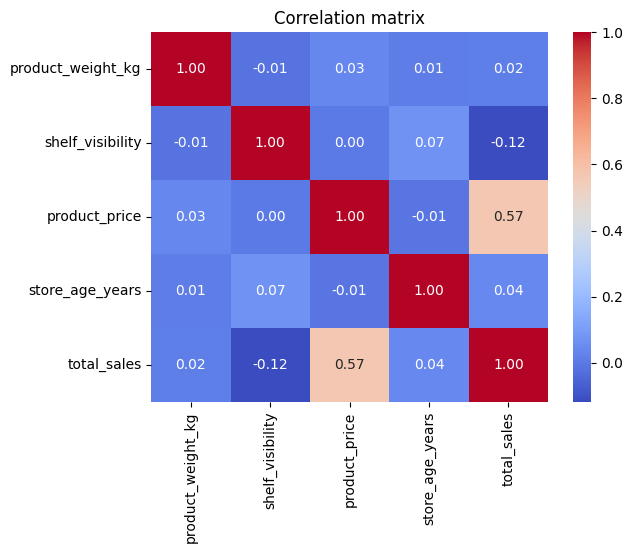

In [16]:
corr_cols = numeric_cols + ['total_sales']
sns.heatmap(train[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

## 3. Data Cleaning

In [17]:
# Case-folds the 48 raw category strings down to the real 16 categories.
full['product_category'] = full['product_category'].str.lower().str.strip()
full['product_category'].value_counts(dropna=False)

,count
product_category,
fruits and vegetables,1232
snack foods,1200
household,910
frozen foods,856
dairy,682
canned,649
baking goods,648
health and hygiene,520
soft drinks,445


### Handling the two missing-data problems

Used a structural approach to handle the missing data problems in the product_weight_kg and store_size columns
The product_weight_kg had 4 products with zero known weight in the entire dataset, category-median fill-in was used
Missingness was more significant in store_size with 3 of the 10 stores (DKU, JOR, OYG) never reporting size at all (rate = 1.0), filled with 'unknown'

In [18]:
missing_rate = (
    full.groupby('product_code')['product_weight_kg']
    .apply(lambda x: x.isnull().mean())
)

missing_rate[missing_rate >= 0.80]

,product_weight_kg
product_code,
PRD-7JH2LK,1.0
PRD-DH3TKZ,1.0
PRD-E6K088,1.0
PRD-GSRI2A,1.0


In [19]:
full.groupby('store_code')['store_size'].apply(lambda x: x.isnull().mean())

,store_size
store_code,
STORE-7WS,0.0
STORE-89Z,0.0
STORE-9RG,0.0
STORE-AGY,0.0
STORE-DKU,1.0
STORE-HL7,0.0
STORE-JOR,1.0
STORE-OYG,1.0
STORE-T5G,0.0


In [20]:
full['store_size'] = full.groupby('store_code')['store_size'].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if x.notnull().any() else x
)
full['store_size'] = full['store_size'].fillna('Unknown')
full['store_size'].value_counts(dropna=False)

,count
store_size,
Medium,2793
Unknown,2410
Small,2388
Large,932


In [21]:
full['product_weight_kg'] = full.groupby('product_code')['product_weight_kg'].transform(
    lambda x: x.fillna(x.mean())
)
full['product_weight_kg'] = full.groupby('product_category')['product_weight_kg'].transform(
    lambda x: x.fillna(x.median())
)
full['product_weight_kg'].isnull().sum()

np.int64(0)

## 4. Feature Engineering

Feature engineering followed directly from the EDA findings above: features
that respect the product/store structure (price normalized by category, visibility
relative to category norms, e.t.c)

In [22]:
full['price_per_kg'] = full['product_price'] / full['product_weight_kg']
full['price_rank_in_category'] = full.groupby('product_category')['product_price'].rank(pct=True)

In [23]:
full["weight_visibility"] = (full["product_weight_kg"] * full["shelf_visibility"])
full["price_visibility"] = (full["product_price"] * full["shelf_visibility"])

In [24]:
cat_mean_vis = full.groupby('product_category')['shelf_visibility'].transform('mean')
full['visibility_ratio'] = full['shelf_visibility'] / cat_mean_vis

In [25]:
full['store_age_years'].describe()

,store_age_years
count,8523.000000
mean,34.168133
std,8.371760
min,23.000000
25%,28.000000
50%,33.000000
75%,45.000000
max,47.000000


Range is 23-47 years (not much to categorise) there was an earlier age-bin but it was dropped.

### Interaction features — checking each one earns its cardinality cost

In [26]:
full['format_tier'] = full['store_format'].astype(str) + "_" + full['store_location_tier'].astype(str)
full['category_fat'] = full['product_category'].astype(str) + "_" + full['fat_content'].astype(str)
full['category_store_type'] = full['product_category'].astype(str) + "_" + full['store_format'].astype(str)

In [27]:
print(full['format_tier'].value_counts())
pd.crosstab(full['store_format'], full['store_location_tier'])

format_tier
Standard Supermarket_Tier_2    2785
Standard Supermarket_Tier_1    1860
Flagship Hypermarket_Tier_3     935
Standard Supermarket_Tier_3     932
Superstore_Tier_3               928
Corner Shop_Tier_3              555
Corner Shop_Tier_1              528
Name: count, dtype: int64


store_location_tier,Tier_1,Tier_2,Tier_3
store_format,,,
Corner Shop,528,0,555
Flagship Hypermarket,0,0,935
Standard Supermarket,1860,2785,932
Superstore,0,0,928


In [28]:
print(full['category_fat'].value_counts())
pd.crosstab(full['product_category'], full['fat_content'])

category_fat
household_Low Fat                910
snack foods_Low Fat              692
fruits and vegetables_Low Fat    630
fruits and vegetables_Regular    602
health and hygiene_Low Fat       520
snack foods_Regular              508
frozen foods_Low Fat             450
dairy_Low Fat                    418
frozen foods_Regular             406
soft drinks_Low Fat              374
canned_Low Fat                   341
baking goods_Low Fat             329
baking goods_Regular             319
canned_Regular                   308
dairy_Regular                    264
meat_Regular                     255
hard drinks_Low Fat              214
meat_Low Fat                     170
others_Low Fat                   169
breads_Low Fat                   140
breads_Regular                   111
starchy foods_Low Fat             82
soft drinks_Regular               71
breakfast_Regular                 69
starchy foods_Regular             66
breakfast_Low Fat                 41
seafood_Low Fat          

fat_content,Low Fat,Regular
product_category,,
baking goods,329,319
breads,140,111
breakfast,41,69
canned,341,308
dairy,418,264
frozen foods,450,406
fruits and vegetables,630,602
hard drinks,214,0
health and hygiene,520,0


In [29]:
print(full['category_store_type'].value_counts())
pd.crosstab(full['product_category'], full['store_format'])

category_store_type
fruits and vegetables_Standard Supermarket    805
snack foods_Standard Supermarket              785
household_Standard Supermarket                597
frozen foods_Standard Supermarket             572
dairy_Standard Supermarket                    450
                                             ... 
breakfast_Superstore                           12
breakfast_Flagship Hypermarket                 11
seafood_Corner Shop                            10
seafood_Flagship Hypermarket                    7
seafood_Superstore                              7
Name: count, Length: 64, dtype: int64


store_format,Corner Shop,Flagship Hypermarket,Standard Supermarket,Superstore
product_category,,,,
baking goods,85,69,426,68
breads,33,31,160,27
breakfast,19,11,68,12
canned,73,72,426,78
dairy,92,67,450,73
frozen foods,103,89,572,92
fruits and vegetables,152,140,805,135
hard drinks,24,23,145,22
health and hygiene,67,60,335,58


In [30]:
full['product_format'] = full['product_code'].astype(str) + "_" + full['store_format'].astype(str)
full['category_store'] = full['product_category'].astype(str) + "_" + full['store_code'].astype(str)

In [31]:
print(full['product_format'].value_counts())
pd.crosstab(full['product_code'], full['store_format'])

product_format
PRD-3A1DU1_Standard Supermarket    6
PRD-ZJZCZV_Standard Supermarket    6
PRD-444NK0_Standard Supermarket    6
PRD-N5F62D_Standard Supermarket    6
PRD-MNUTT1_Standard Supermarket    6
                                  ..
PRD-DQHDK3_Flagship Hypermarket    1
PRD-ZGVTUI_Superstore              1
PRD-H0JJGG_Flagship Hypermarket    1
PRD-MLWBFJ_Superstore              1
PRD-VLTBHO_Flagship Hypermarket    1
Name: count, Length: 4314, dtype: int64


store_format,Corner Shop,Flagship Hypermarket,Standard Supermarket,Superstore
product_code,,,,
PRD-00CVW9,0,0,4,1
PRD-00EIUE,2,1,3,0
PRD-00V830,0,1,1,0
PRD-02NFGI,1,1,4,1
PRD-031L36,1,1,4,0
...,...,...,...,...
PRD-ZTO1FG,1,0,5,0
PRD-ZVRERW,2,0,3,1
PRD-ZWW54A,2,0,4,1


In [32]:
print(full['category_store'].value_counts())
pd.crosstab(full['product_category'], full['store_code'])

category_store
fruits and vegetables_STORE-DKU    143
fruits and vegetables_STORE-AGY    142
fruits and vegetables_STORE-7WS    140
snack foods_STORE-9RG              140
snack foods_STORE-89Z              139
                                  ... 
seafood_STORE-YLW                    6
seafood_STORE-AGY                    5
seafood_STORE-OYG                    5
starchy foods_STORE-T5G              4
seafood_STORE-JOR                    4
Name: count, Length: 160, dtype: int64


store_code,STORE-7WS,STORE-89Z,STORE-9RG,STORE-AGY,STORE-DKU,STORE-HL7,STORE-JOR,STORE-OYG,STORE-T5G,STORE-YLW
product_category,,,,,,,,,,
baking goods,69,66,68,73,70,68,42,73,43,76
breads,31,25,29,25,33,27,17,22,16,26
breakfast,11,13,10,13,10,12,9,12,10,10
canned,72,67,79,65,74,78,35,69,38,72
dairy,67,78,71,80,69,73,43,74,49,78
frozen foods,89,93,92,92,81,92,54,106,49,108
fruits and vegetables,140,138,129,142,143,135,79,127,73,126
hard drinks,23,30,22,23,28,22,16,22,8,20
health and hygiene,60,52,50,61,55,58,37,61,30,56


In [33]:
full = full.drop(columns=['price_rank_in_category'])
# full = full.drop(columns=['visibility_ratio'])

In [34]:
train = full[full['is_train'] == 1].drop(columns=['is_train']).reset_index(drop=True)
test = full[full['is_train'] == 0].drop(columns=['is_train', 'total_sales']).reset_index(drop=True)
train.shape, test.shape

((6818, 22), (1705, 21))

### Encoding the high-cardinality columns safely

K-fold target encoding (encode each fold using only the OTHER folds' target means) to avoid leaking total_sales into its own encoding. Applied to product_code, product_category, category_store and product_format

In [35]:
def kfold_target_encode(train_df, test_df, col, target, n_splits=5, seed=SEED):
    train_encoded = np.zeros(len(train_df))
    kf_te = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    global_mean = train_df[target].mean()

    for tr_idx, val_idx in kf_te.split(train_df):
        means = train_df.iloc[tr_idx].groupby(col)[target].mean()
        train_encoded[val_idx] = train_df.iloc[val_idx][col].map(means).fillna(global_mean)

    full_means = train_df.groupby(col)[target].mean()
    test_encoded = test_df[col].map(full_means).fillna(global_mean)
    return train_encoded, test_encoded

for col in ['product_code', 'product_category', 'category_store', 'product_format']:
    train[f'{col}_target_enc'], test[f'{col}_target_enc'] = kfold_target_encode(
        train, test, col, 'total_sales'
    )

In [36]:
categorical_features = ['category_store_type', 'fat_content', 'store_size', 'store_location_tier',
                        'store_format', 'store_code', 'format_tier', 'category_fat']
for col in categorical_features:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

exclude_cols = ['id', 'product_code','product_category', 'category_store', 'product_format', 'total_sales', 'log_total_sales']
feature_cols = [c for c in train.columns if c not in exclude_cols]

X = train[feature_cols]
y = train['total_sales']


X_test = test[feature_cols]

print(f"{len(feature_cols)} features:", feature_cols)

20 features: ['product_weight_kg', 'fat_content', 'shelf_visibility', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'price_per_kg', 'weight_visibility', 'price_visibility', 'visibility_ratio', 'format_tier', 'category_fat', 'category_store_type', 'product_code_target_enc', 'product_category_target_enc', 'category_store_target_enc', 'product_format_target_enc']


In [37]:
# Get list of numerical columns and their count
num_cols = list(train.select_dtypes(include=['number']).columns)
num_count = len(num_cols)

# Get list of categorical columns and their count
cat_cols = list(train.select_dtypes(include=['object', 'category']).columns)
cat_count = len(cat_cols)

print(f"Numerical Columns ({num_count}): {num_cols}")
print(f"Categorical Columns ({cat_count}): {cat_cols}")

Numerical Columns (13): ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales', 'price_per_kg', 'weight_visibility', 'price_visibility', 'visibility_ratio', 'product_code_target_enc', 'product_category_target_enc', 'category_store_target_enc', 'product_format_target_enc']
Categorical Columns (13): ['id', 'product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format', 'format_tier', 'category_fat', 'category_store_type', 'product_format', 'category_store']


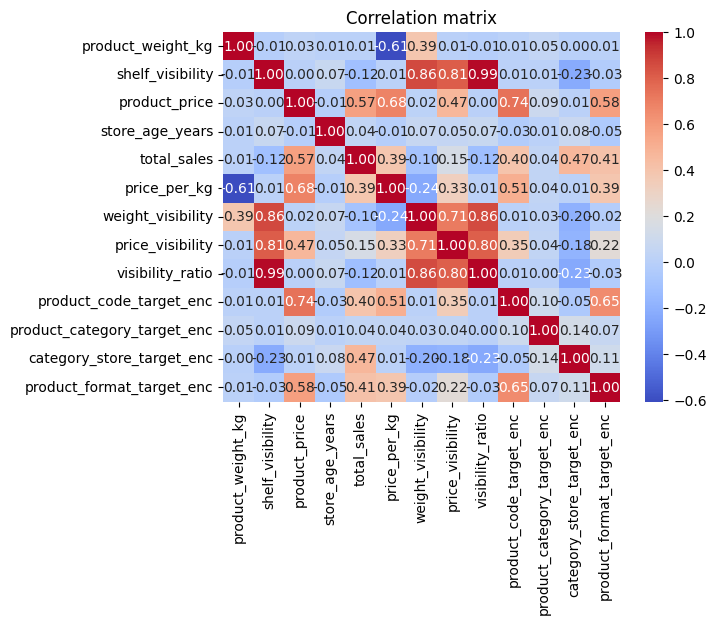

In [38]:
corr_cols = num_cols
sns.heatmap(train[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

### Multicollinearity check (VIF)
VIF on the continuous numerics to
check whether any interaction feature is functionally
redundant with the columns it's built from. This part wasnt really necessary as the tree models are in a way capable of resolving that

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

numeric_vif_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales', 'price_per_kg', 'weight_visibility', 'price_visibility', 'product_code_target_enc', 'product_category_target_enc', 'category_store_target_enc', 'product_format_target_enc']

X_num_vif = add_constant(train[numeric_vif_cols])
vif_numeric = pd.DataFrame({
    'feature': X_num_vif.columns,
    'VIF': [variance_inflation_factor(X_num_vif.values, i) for i in range(X_num_vif.shape[1])]
})
vif_numeric[vif_numeric['feature'] != 'const'].sort_values('VIF', ascending=False)

,feature,VIF
2,shelf_visibility,13.498418
7,weight_visibility,10.396385
3,product_price,8.531137
8,price_visibility,7.788067
6,price_per_kg,7.188133
1,product_weight_kg,5.378452
9,product_code_target_enc,2.739756
5,total_sales,2.229926
12,product_format_target_enc,1.881731
11,category_store_target_enc,1.612139


## 5. Baseline Cross-Validated Models

Three gradient-boosted models plus the structural model. The tree models learn from the full
feature set, and the structural model from an explicit price x throughput hypothesis alone.

Baseline models trained on default hyperparameters, before Optuna tuning, to get a first read on where each algorithm stands.

In [40]:
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [41]:
# one-hot version for models that don't take native categoricals (XGBoost here, Ridge later)
X_xgb = pd.get_dummies(X, columns=categorical_features)
X_test_xgb = pd.get_dummies(X_test, columns=categorical_features)
X_xgb, X_test_xgb = X_xgb.align(X_test_xgb, join='left', axis=1, fill_value=0)

cat_feature_idx = [X.columns.get_loc(c) for c in categorical_features]

In [42]:
oof_lgb = np.zeros(len(X))
pred_lgb = np.zeros(len(X_test))

lgb_params = dict(objective='regression', metric='rmse', learning_rate=0.05,
                   num_leaves=31, random_state=SEED, verbosity=-1)

for tr_idx, val_idx in kf.split(X):
    model = lgb.LGBMRegressor(**lgb_params, n_estimators=2000)
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(100, verbose=False)])
    oof_lgb[val_idx] = model.predict(X.iloc[val_idx])
    pred_lgb += model.predict(X_test) / N_FOLDS

print("LightGBM OOF RMSE (original scale):", rmse(y, oof_lgb))

LightGBM OOF RMSE (original scale): 1088.965279138317


In [43]:
oof_xgb = np.zeros(len(X))
pred_xgb = np.zeros(len(X_test))

xgb_params = dict(objective='reg:squarederror', learning_rate=0.05, max_depth=6, random_state=SEED)

for tr_idx, val_idx in kf.split(X_xgb):
    model = xgb.XGBRegressor(**xgb_params, n_estimators=2000, early_stopping_rounds=100)
    model.fit(X_xgb.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X_xgb.iloc[val_idx], y.iloc[val_idx])], verbose=False)
    oof_xgb[val_idx] = model.predict(X_xgb.iloc[val_idx])
    pred_xgb += model.predict(X_test_xgb) / N_FOLDS

print("XGBoost OOF RMSE (original scale):", rmse(y, oof_xgb))

XGBoost OOF RMSE (original scale): 1083.2218356065684


In [44]:
oof_cat = np.zeros(len(X))
pred_cat = np.zeros(len(X_test))

for tr_idx, val_idx in kf.split(X):
    model = CatBoostRegressor(iterations=2000, learning_rate=0.05, depth=6,
                               random_seed=SEED, verbose=False, early_stopping_rounds=100)
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=(X.iloc[val_idx], y.iloc[val_idx]), cat_features=cat_feature_idx)
    oof_cat[val_idx] = model.predict(X.iloc[val_idx])
    pred_cat += model.predict(X_test) / N_FOLDS

print("CatBoost OOF RMSE (original scale):", rmse(y, oof_cat))

CatBoost OOF RMSE (original scale): 1071.4471420382918


Structural model: an explicit hypothesis (total_sales ~ store throughput x product
price), not a generic learner. It never sees product_category, store_format, or any
engineered feature.
Repeated across 3 seeds x 5 folds to smooth out OOF noise

In [45]:
SEEDS = [42, 202, 2024]
ALPHA = 40

_pg = full.groupby(full['product_code'].astype(str))['product_price']
TRUE_PRICE = (_pg.max() + _pg.min()) / 2

def structural_model(tr_idx, alpha):
    d = train.iloc[tr_idx]
    store = d['store_code'].astype(str)
    product = d['product_code'].astype(str)

    p = product.map(TRUE_PRICE).values
    k = pd.Series(d['total_sales'].values / p).groupby(store.values).mean()
    r = d['total_sales'].values / (store.map(k).values * p) - 1
    g = pd.DataFrame({'p': product.values, 'r': r}).groupby('p')['r'].agg(['sum', 'count'])
    eff = g['sum'] / (g['count'] + alpha)

    return lambda f: (
        f['store_code'].astype(str).map(k).values
        * f['product_code'].astype(str).map(TRUE_PRICE).values
        * (1 + f['product_code'].astype(str).map(eff).fillna(0).values)
    )

oof_structural = np.zeros(len(train))
for s in SEEDS:
    for tr_idx, val_idx in KFold(n_splits=N_FOLDS, shuffle=True, random_state=s).split(train):
        oof_structural[val_idx] += structural_model(tr_idx, ALPHA)(train.iloc[val_idx]) / len(SEEDS)

pred_structural = structural_model(np.arange(len(train)), ALPHA)(test)

print("Structural model OOF RMSE:", rmse(y, oof_structural))

Structural model OOF RMSE: 1069.4920039324265


## 6. Hyperparameter Tuning with Optuna

5-fold CV inside each Optuna trial, 50 trials per model, TPE sampler with median
pruning to cut off clearly bad trials early.

In [46]:
def lgb_objective(trial):
    params = {
        'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'random_state': SEED,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    scores = []
    for tr_idx, val_idx in kf.split(X):
        model = lgb.LGBMRegressor(**params, n_estimators=2000)
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx],
                  eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
        scores.append(rmse(y.iloc[val_idx], model.predict(X.iloc[val_idx])))
    return np.mean(scores)

study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED),
                                 pruner=optuna.pruners.MedianPruner())
study_lgb.optimize(lgb_objective, n_trials=50)
print("Best LightGBM params:", study_lgb.best_params)
print("Best CV RMSE (log scale):", study_lgb.best_value)

Best LightGBM params: {'learning_rate': 0.017087028354224768, 'num_leaves': 58, 'max_depth': 4, 'min_child_samples': 8, 'subsample': 0.7464578711851276, 'colsample_bytree': 0.9568494476923409, 'reg_alpha': 0.09823718958872545, 'reg_lambda': 6.558361537877922e-07}
Best CV RMSE (log scale): 1081.1822421829586


In [47]:
def xgb_objective(trial):
    params = {
        'objective': 'reg:squarederror', 'random_state': SEED,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    scores = []
    for tr_idx, val_idx in kf.split(X_xgb):
        model = xgb.XGBRegressor(**params, n_estimators=2000, early_stopping_rounds=100)
        model.fit(X_xgb.iloc[tr_idx], y.iloc[tr_idx],
                  eval_set=[(X_xgb.iloc[val_idx], y.iloc[val_idx])], verbose=False)
        scores.append(rmse(y.iloc[val_idx], model.predict(X_xgb.iloc[val_idx])))
    return np.mean(scores)

study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=50)
print("Best XGBoost params:", study_xgb.best_params)

Best XGBoost params: {'learning_rate': 0.010447276598356372, 'max_depth': 4, 'subsample': 0.785617205870811, 'colsample_bytree': 0.7904509197053847, 'min_child_weight': 8, 'reg_alpha': 1.544217507008402e-05, 'reg_lambda': 0.8736748511819046}


In [48]:
def cat_objective(trial):
    params = {
        'iterations': 2000, 'random_seed': SEED, 'verbose': False,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
    }
    scores = []
    for tr_idx, val_idx in kf.split(X):
        model = CatBoostRegressor(**params, early_stopping_rounds=100)
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx],
                  eval_set=(X.iloc[val_idx], y.iloc[val_idx]), cat_features=cat_feature_idx)
        scores.append(rmse(y.iloc[val_idx], model.predict(X.iloc[val_idx])))
    return np.mean(scores)

study_cat = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(cat_objective, n_trials=50)
print("Best CatBoost params:", study_cat.best_params)

Best CatBoost params: {'learning_rate': 0.03665130719547918, 'depth': 6, 'l2_leaf_reg': 8.600177493316712, 'bagging_temperature': 0.7798282607498942}


## 7. Retrain Tuned Models & Generate Final OOF / Test Predictions

Refitting the three models with the Optuna-tuned hyperparameters, generating
the final OOF and test predictions that feed the ensemble after.

In [49]:
oof_lgb_tuned = np.zeros(len(X))
pred_lgb_tuned = np.zeros(len(X_test))
best_lgb_params = {**study_lgb.best_params, 'objective': 'regression', 'metric': 'rmse',
                    'random_state': SEED, 'verbosity': -1}

for tr_idx, val_idx in kf.split(X):
    model = lgb.LGBMRegressor(**best_lgb_params, n_estimators=2000)
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(100, verbose=False)])
    oof_lgb_tuned[val_idx] = model.predict(X.iloc[val_idx])
    pred_lgb_tuned += model.predict(X_test) / N_FOLDS

print("Tuned LightGBM RMSE:", rmse(y, oof_lgb_tuned))

Tuned LightGBM RMSE: 1081.4804548113727


In [50]:
oof_xgb_tuned = np.zeros(len(X))
pred_xgb_tuned = np.zeros(len(X_test))
best_xgb_params = {**study_xgb.best_params, 'objective': 'reg:squarederror', 'random_state': SEED}

for tr_idx, val_idx in kf.split(X_xgb):
    model = xgb.XGBRegressor(**best_xgb_params, n_estimators=2000, early_stopping_rounds=100)
    model.fit(X_xgb.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X_xgb.iloc[val_idx], y.iloc[val_idx])], verbose=False)
    oof_xgb_tuned[val_idx] = model.predict(X_xgb.iloc[val_idx])
    pred_xgb_tuned += model.predict(X_test_xgb) / N_FOLDS

print("Tuned XGBoost RMSE:", rmse(y, oof_xgb_tuned))

Tuned XGBoost RMSE: 1076.749425413148


In [51]:
oof_cat_tuned = np.zeros(len(X))
pred_cat_tuned = np.zeros(len(X_test))
best_cat_params = {**study_cat.best_params, 'random_seed': SEED, 'verbose': False}

for tr_idx, val_idx in kf.split(X):
    model = CatBoostRegressor(**best_cat_params, iterations=2000, early_stopping_rounds=100)
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=(X.iloc[val_idx], y.iloc[val_idx]), cat_features=cat_feature_idx)
    oof_cat_tuned[val_idx] = model.predict(X.iloc[val_idx])
    pred_cat_tuned += model.predict(X_test) / N_FOLDS

print("Tuned CatBoost RMSE:", rmse(y, oof_cat_tuned))

Tuned CatBoost RMSE: 1071.1797819833373


## 8. Ensemble

In [52]:
oof_matrix = np.vstack([oof_xgb_tuned, oof_cat_tuned, oof_structural]).T
pred_matrix = np.vstack([pred_xgb_tuned, pred_cat_tuned, pred_structural]).T

def blend_loss(weights):
    w = np.abs(weights) / np.sum(np.abs(weights))
    blend = oof_matrix @ w
    return rmse(y, blend)

init_weights = np.ones(oof_matrix.shape[1]) / oof_matrix.shape[1]
result = minimize(blend_loss, init_weights, method='Nelder-Mead')
best_weights = np.abs(result.x) / np.sum(np.abs(result.x))

print("Best blend weights (lgb, xgb, cat, ridge):", best_weights)
print("Blend OOF RMSE:", blend_loss(result.x))

Best blend weights (lgb, xgb, cat, ridge): [0.13245772 0.28668    0.58086227]
Blend OOF RMSE: 1067.4487818427713


In [53]:
meta_model = Ridge(alpha=1.0)
meta_model.fit(oof_matrix, y)
oof_stack = meta_model.predict(oof_matrix)
pred_stack = meta_model.predict(pred_matrix)

print("Stacked OOF RMSE:", rmse(y, oof_stack))

Stacked OOF RMSE: 1067.4229199164113


In [54]:
blend_rmse = blend_loss(result.x)
stack_rmse = rmse(y, oof_stack)

if stack_rmse < blend_rmse:
    print(f"Using stacked ensemble ({stack_rmse:.4f} < {blend_rmse:.4f})")
    final_pred = pred_stack
else:
    print(f"Using weighted blend ({blend_rmse:.4f} <= {stack_rmse:.4f})")
    final_pred = pred_matrix @ best_weights

Using stacked ensemble (1067.4229 < 1067.4488)


## 9. Submission

In [55]:
final_pred = np.clip(final_pred, 0, None)

submission = pd.DataFrame({
    'id': test['id'],
    'total_sales': final_pred
})

submission.to_csv('submission.csv', index=False)
submission.head()

,id,total_sales
0,row_00009,2749.391443
1,row_00015,4552.398645
2,row_00019,3030.059701
3,row_00020,3216.249445
4,row_00023,2477.203103


In [56]:
print("Prediction stats:")
print(submission['total_sales'].describe())
print("\nTrain target stats:")
print(train['total_sales'].describe())

from google.colab import files
files.download('submission.csv')

Prediction stats:
count    1705.000000
mean     2194.205644
std      1320.856941
min        69.087990
25%      1169.672718
50%      2065.256510
75%      3090.491850
max      6573.454446
Name: total_sales, dtype: float64

Train target stats:
count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>